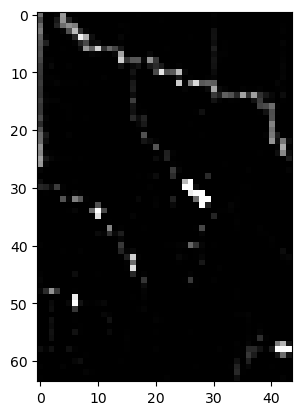

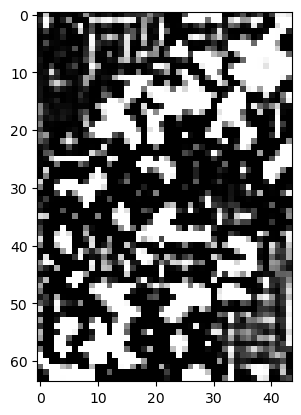

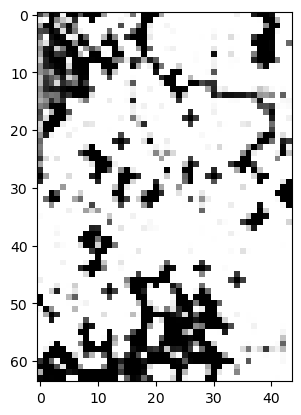

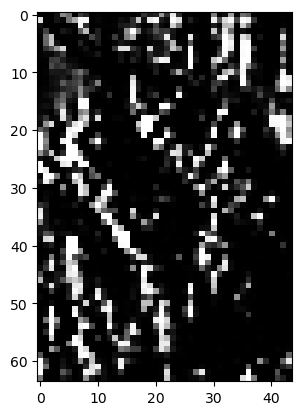

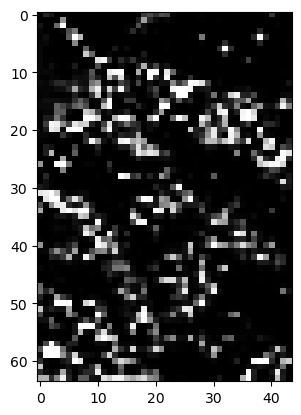

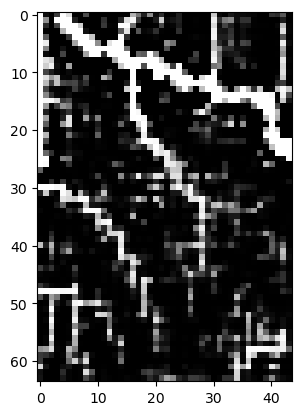

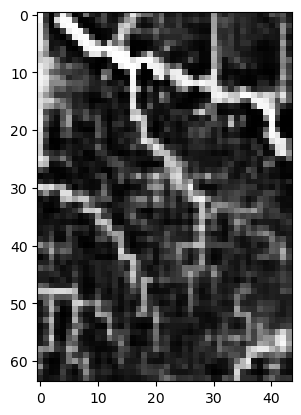

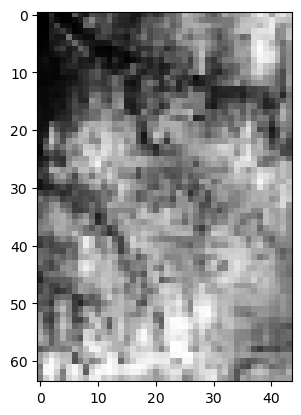

In [1]:
import numpy as np
import matplotlib.pyplot as plt

output_tensor = np.load("HR_1000m_tensor_8_channels.npy")

for i in range(0, 8):
    plt.imshow(output_tensor[0, i], cmap='gray')
#     plt.settitle(str(i) + "th channel")
#     fig.colorbar(im, ax=axes[i])
    plt.show()

# plt.tight_layout()
plt.close()

(1, 8, 64, 44)
(1, 8, 32, 22)
(64, 44)
(1, 8, 32, 22)


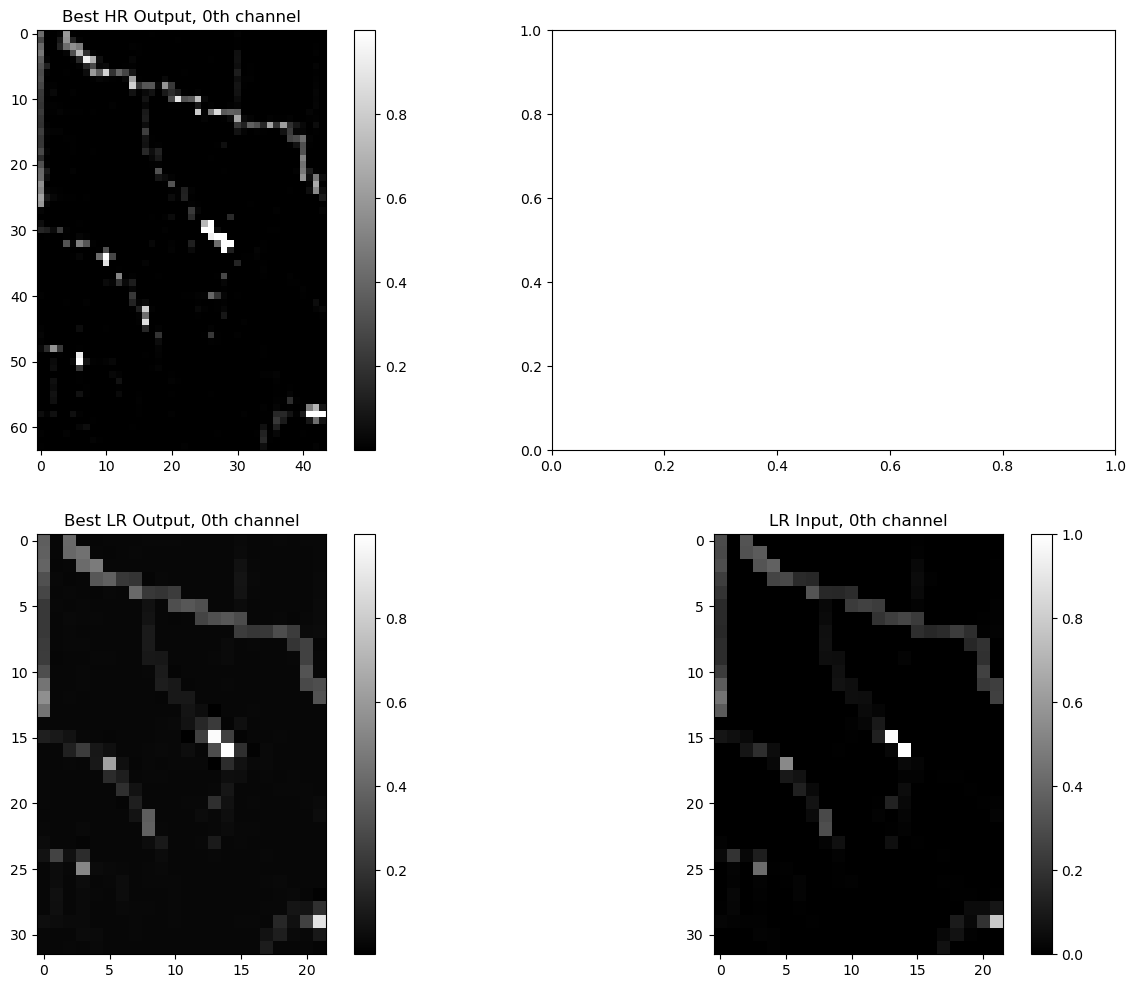

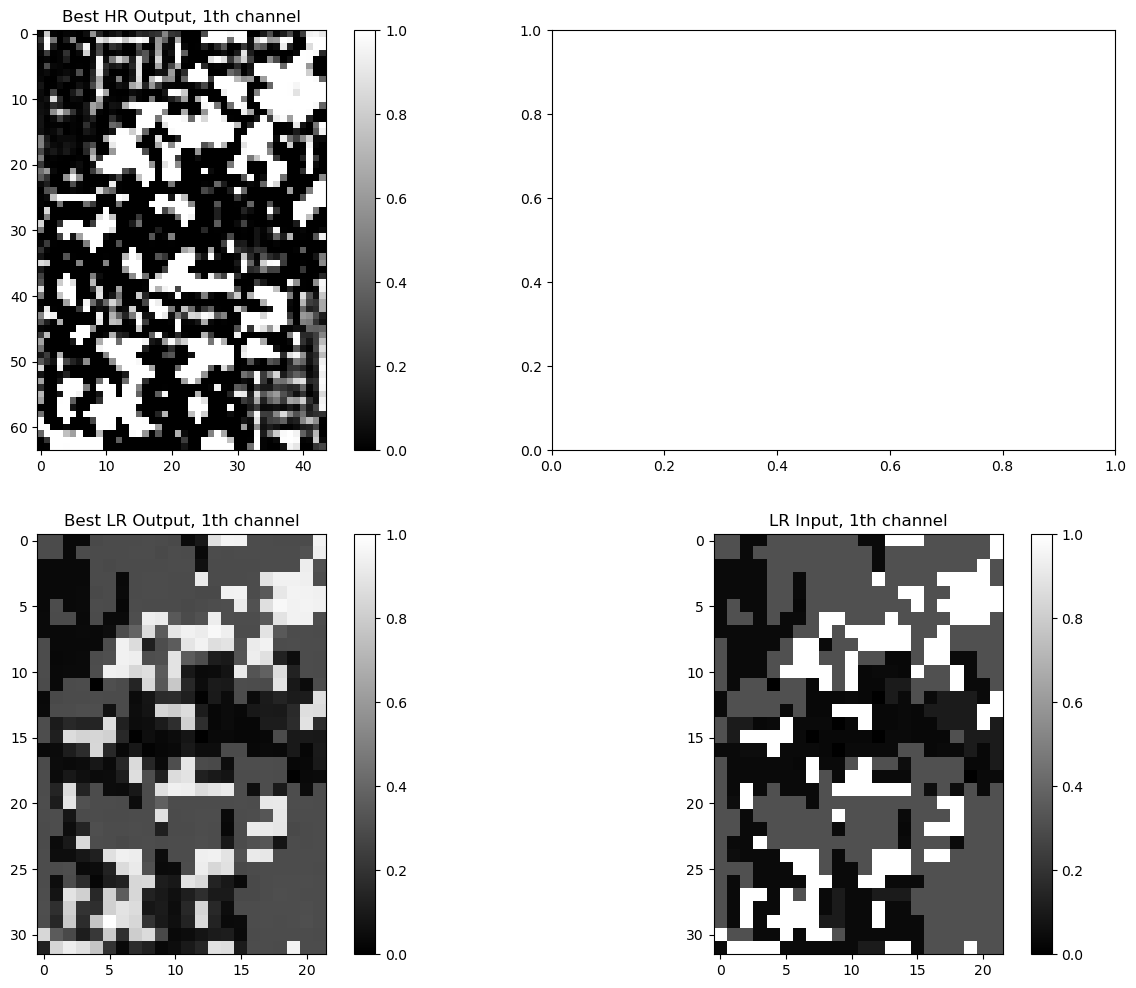

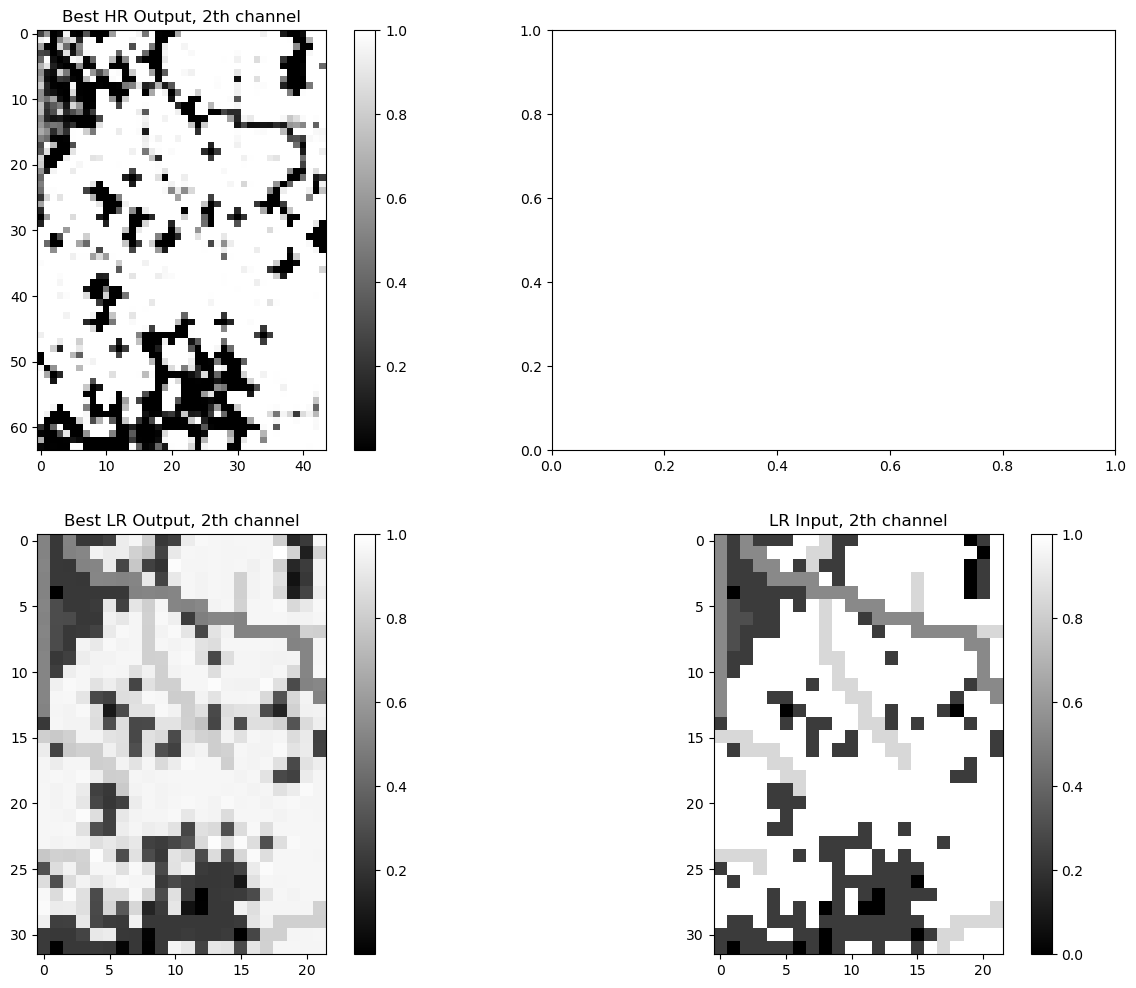

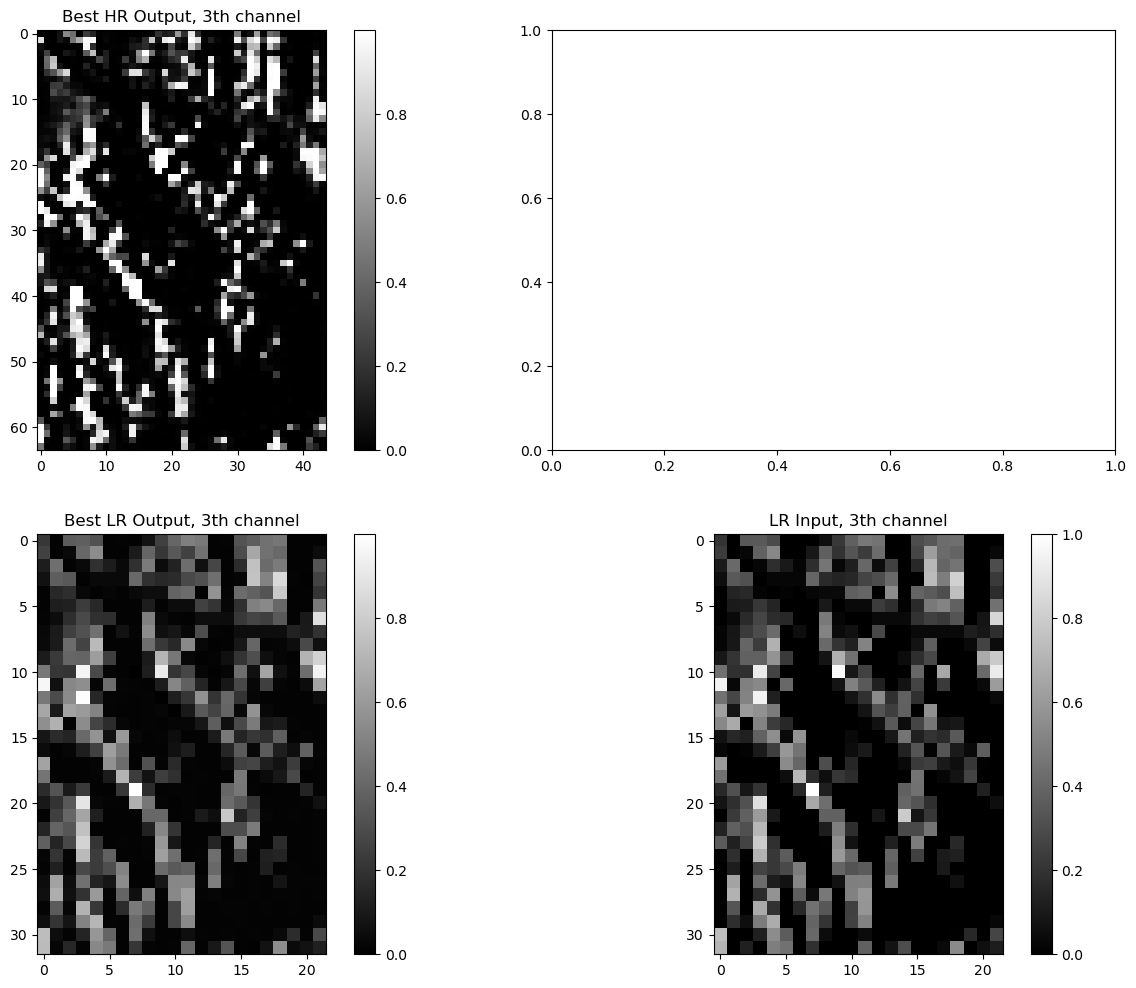

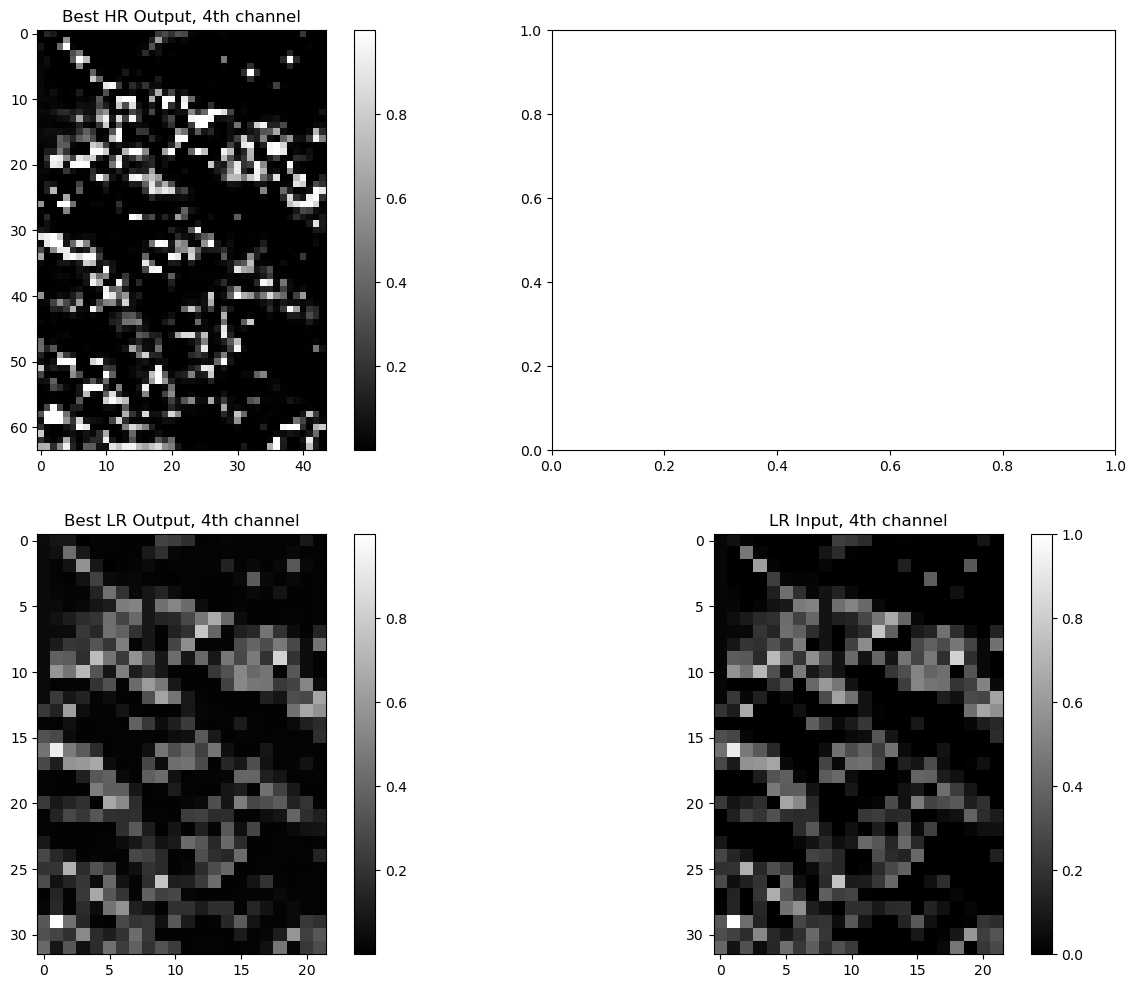

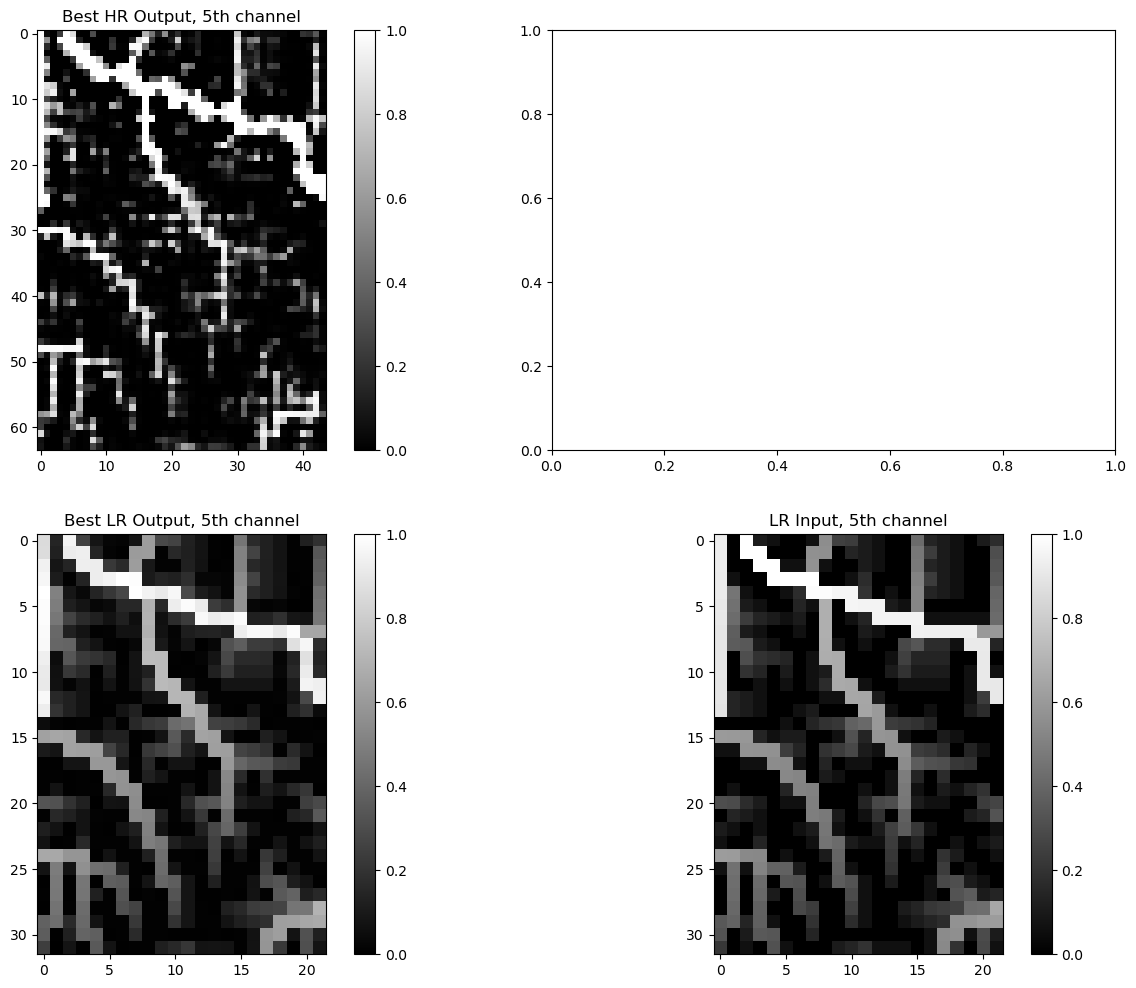

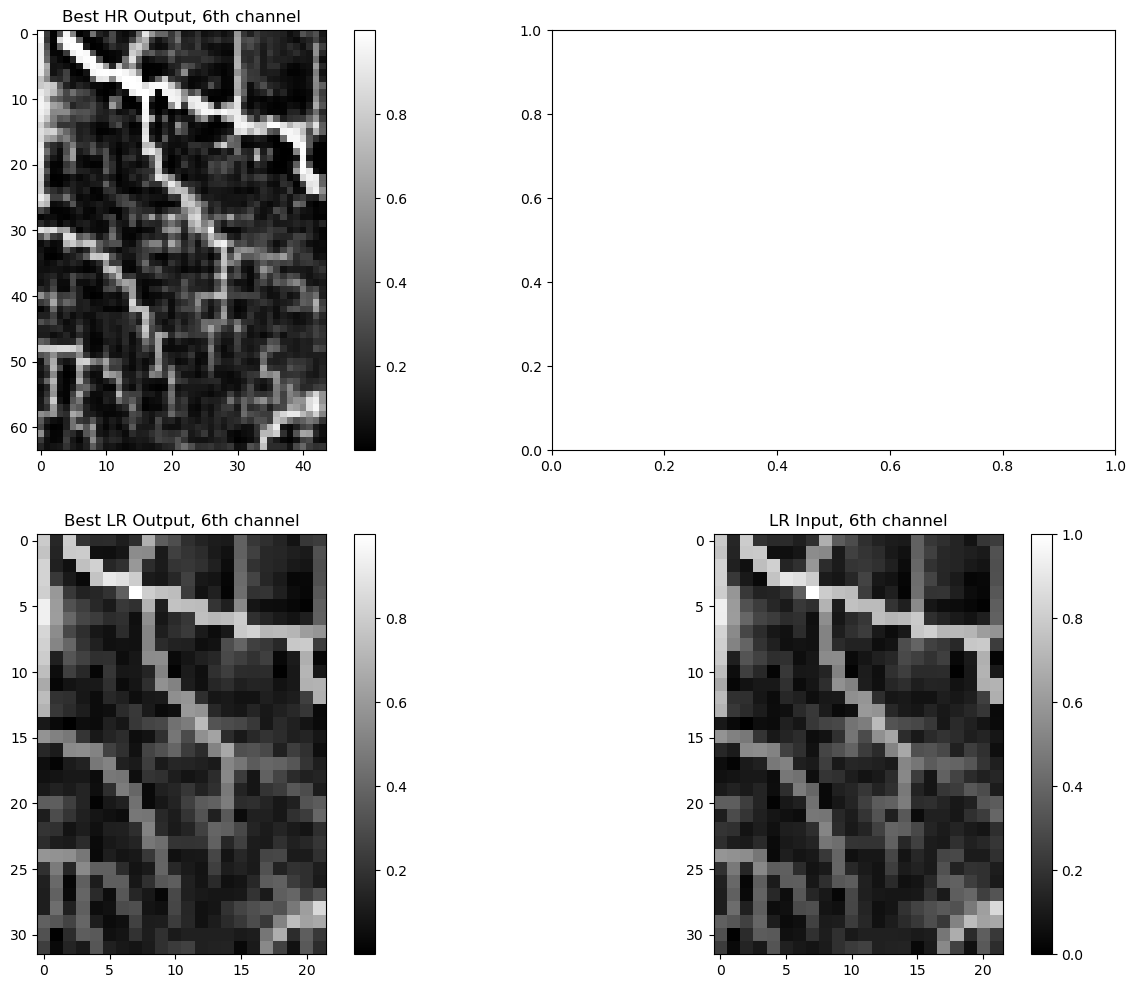

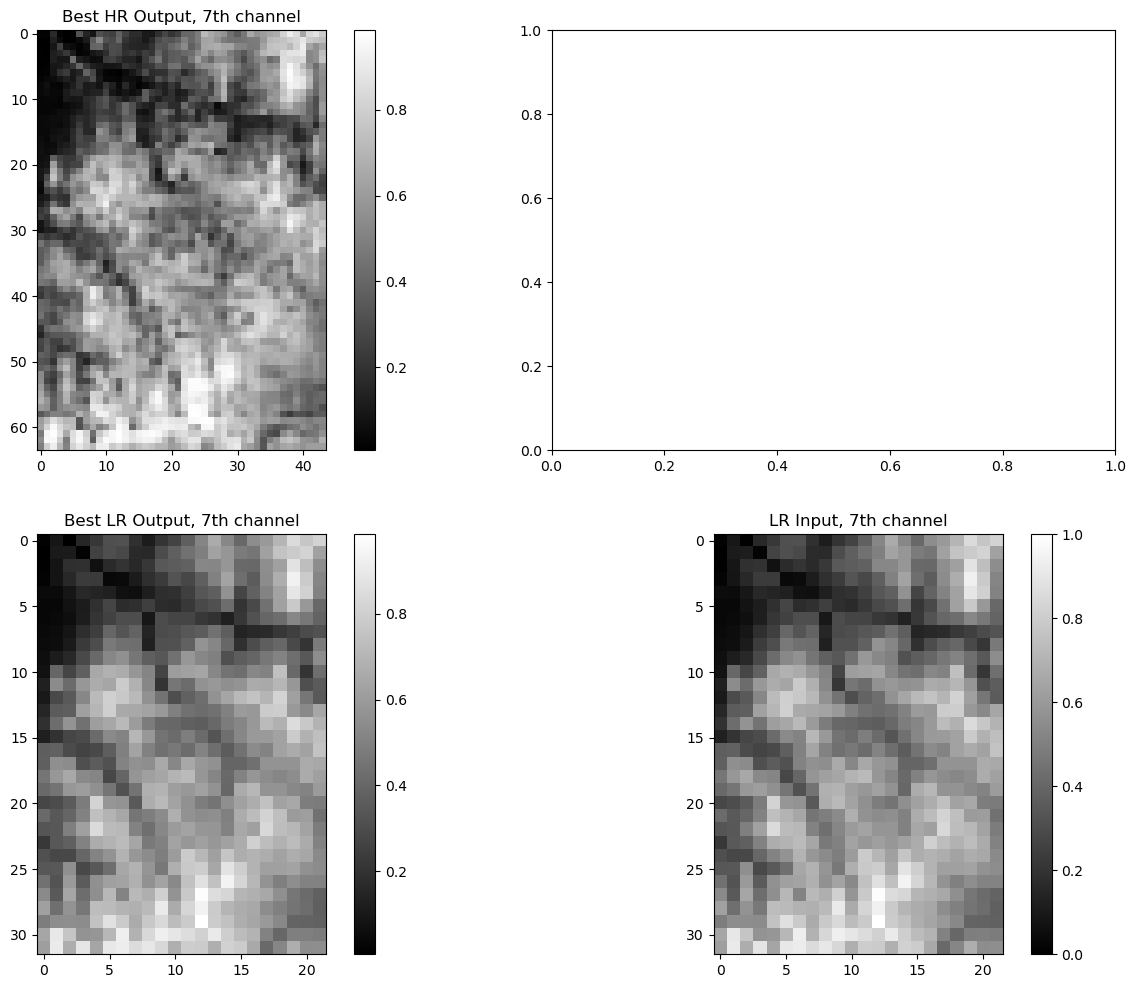

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.metrics import r2_score

out_HR_final = np.load("HR_1000m_tensor_8_channels.npy")
out_LR_final = np.load("LR_500m_tensor_8_channels.npy")
HR_tensor = np.load("/home/nk1495/deep-image-prior/data/sr/label_500m_tensor.npy")
LR_tensor = np.load("/home/nk1495/deep-image-prior/data/sr/input_1000m_tensor.npy")

print(out_HR_final.shape)
print(out_LR_final.shape)
print(HR_tensor.shape)
print(LR_tensor.shape)

for i in range(0, 8):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    im00 = axes[0][0].imshow(out_HR_final[0, i], cmap='gray')
    axes[0][0].set_title(f"Best HR Output, {i}th channel")
    fig.colorbar(im00, ax=axes[0][0])
    
#     im01 = axes[0][1].imshow(HR_tensor[0, i], cmap='gray')
#     axes[0][1].set_title(f"HR Label, {i}th channel")
#     fig.colorbar(im01, ax=axes[0][1])
    
    im10 = axes[1][0].imshow(out_LR_final[0, i], cmap='gray')
    axes[1][0].set_title(f"Best LR Output, {i}th channel")
    fig.colorbar(im00, ax=axes[1][0])
    
    im11 = axes[1][1].imshow(LR_tensor[0, i], cmap='gray')
    axes[1][1].set_title(f"LR Input, {i}th channel")
    fig.colorbar(im11, ax=axes[1][1])

# plt.tight_layout()
plt.show()
# plt.savefig("training_outputs/comparison.png", bbox_inches="tight")
plt.close()

(1, 8, 64, 44)
(64, 44)
(1, 8, 32, 22)
(1, 8, 32, 22)
1.0
1e-07
1.0
1e-07
-0.24400511010970913
0.9746801980015611
Min: -16.118095
Max: 0.0


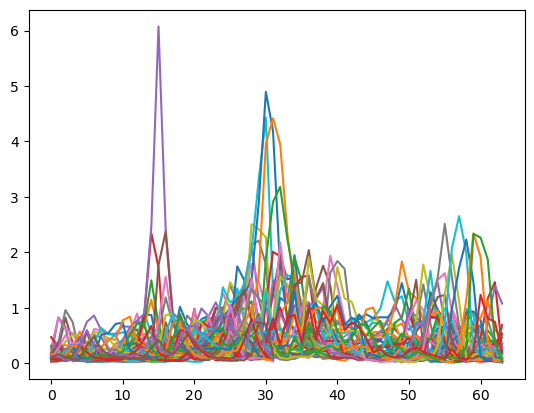

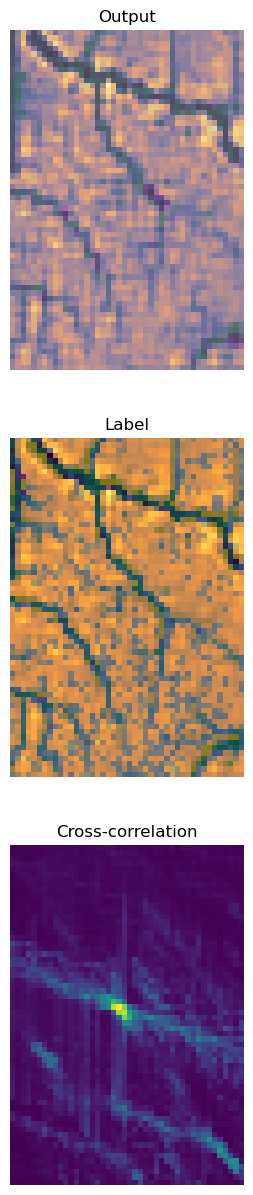

In [7]:
import matplotlib.colors as colors

print(out_HR_final.shape)
print(HR_tensor.shape)
print(out_LR_final.shape)
print(LR_tensor.shape)

HR_tensor[HR_tensor == 0] = 0.0000001
LR_tensor[LR_tensor == 0] = 0.0000001

print(LR_tensor[0][0].max())
print(LR_tensor[0][0].min())
print(HR_tensor.max())
print(HR_tensor.min())

corr_HR = signal.correlate2d(out_HR_final[0][0], HR_tensor, mode='same')
plt.plot(corr_HR)

corr_LR = signal.correlate2d(out_LR_final[0][0], LR_tensor[0][0], mode='same')
plt.plot(corr_LR)

print(r2_score(out_HR_final[0][0], HR_tensor))
print(r2_score(out_LR_final[0][0], LR_tensor[0][0]))

import matplotlib.pyplot as plt
fig, (ax_orig, ax_template, ax_corr) = plt.subplots(3, 1,
                                                    figsize=(6, 15))
ax_orig.imshow(1 - np.log(out_HR_final[0][0]), cmap='viridis', norm=colors.LogNorm(vmin=(1 - np.log(out_HR_final[0][0])).min(), vmax=(1 - np.log(out_HR_final[0][0])).max()), alpha=0.5)
ax_orig.imshow(1 - np.log(out_HR_final[0][6]), cmap='magma', norm=colors.LogNorm(vmin=(1 - np.log(out_HR_final[0][6])).min(), vmax=(1 - np.log(out_HR_final[0][6])).max()), alpha=0.5)
ax_orig.set_title('Output')
ax_orig.set_axis_off()

ax_template.imshow(1 - np.log(HR_tensor), cmap='viridis', norm=colors.LogNorm(vmin=(1 - np.log(HR_tensor)).min(), vmax=(1 - np.log(HR_tensor)).max()))
print("Min: " + str(np.log(HR_tensor).min()))
print("Max: " + str(np.log(HR_tensor).max()))
ax_template.imshow(1 - np.log(out_HR_final[0][6]), cmap='magma', norm=colors.LogNorm(vmin=(1 - np.log(out_HR_final[0][6])).min(), vmax=(1 - np.log(out_HR_final[0][6])).max()), alpha=0.5)
ax_template.set_title('Label')
ax_template.set_axis_off()

ax_corr.imshow(corr_HR, cmap='viridis')
ax_corr.set_title('Cross-correlation')
ax_corr.set_axis_off()
ax_orig.plot('ro')
fig.show()